Importing Data

In [3]:
import pandas as pd
import numpy as np

data_dir = '/home/ethan-xiao/food-allergy-biomarkers/data'

meta = pd.read_csv(f'{data_dir}/sample_info.csv')

X = pd.DataFrame(
    np.load(f'{data_dir}/combat_noMod.npy'),
    index=pd.read_csv(f'{data_dir}/probe_ids.csv')['probe_id'],
    columns=meta['sample_id']
)

is_114134 = (meta['cohort'] == 'GSE114134').values
is_189148 = (meta['cohort'] == 'GSE189148').values
y = (meta['allergy_status'] == 'allergic').astype(int).values

print(X.shape)
print((X.columns == meta['sample_id']).all())

(751107, 102)
True


Applying Variance Filter

In [5]:
import pandas as pd

is_114134 = (meta['cohort'] == 'GSE114134').values
is_189148 = (meta['cohort'] == 'GSE189148').values

VAR_QUANTILE = 0.80

def variance_filter(X, train_mask, quantile=VAR_QUANTILE):
    v = X.loc[:, train_mask].var(axis=1)
    cutoff = v.quantile(quantile)
    return X.index[v > cutoff]

#Fold A trains on GSE114134, Fold B trains on GSE189148
probes_foldA = variance_filter(X, is_114134)
probes_foldB = variance_filter(X, is_189148)

print(f"Fold A: {len(probes_foldA):,}")
print(f"Fold B: {len(probes_foldB):,}")
print(f"Overlap: {len(probes_foldA.intersection(probes_foldB)):,}")

Fold A universe: 150,222
Fold B universe: 150,222
Overlap: 128,624


In [6]:
import sklearn.feature_selection
from sklearn.feature_selection import f_classif

y = (meta['allergy_status'] == 'allergic').astype(int).values

def univariate_rank(X, probes, train_mask, y, top_n=2000):
    Xtr = X.loc[probes, train_mask].T.values
    ytr = y[train_mask]
    F, p = f_classif(Xtr, ytr)
    ranked = pd.Series(p, index=probes).sort_values()
    return ranked.index[:top_n], ranked

foldA_top, foldA_p = univariate_rank(X, probes_foldA, is_114134, y) #Now top 2000 only
foldB_top, foldB_p = univariate_rank(X, probes_foldB, is_189148, y)

print((foldA_p < 0.05).sum(), (foldB_p < 0.05).sum())
print(len(foldA_top.intersection(foldB_top)))

13034 3128
25


Stability Selection

In [7]:
import warnings
warnings.filterwarnings('ignore')


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter

def stability_select(X, probes, train_mask, y, n_boot=500, C=0.1, seed=42):
    Xtr = X.loc[probes, train_mask].T.values
    ytr = y[train_mask]
    counts = Counter()

    splitter = StratifiedShuffleSplit(
        n_splits=n_boot, train_size=0.5, random_state=seed
    )

    for idx, _ in splitter.split(Xtr, ytr):
        Xs = StandardScaler().fit_transform(Xtr[idx])
        clf = LogisticRegression(
            penalty='l1', C=C, solver='liblinear', max_iter=2000
        ).fit(Xs, ytr[idx])
        selected = np.array(probes)[clf.coef_[0] != 0]
        counts.update(selected)

    freq = pd.Series(counts, dtype=float).reindex(probes, fill_value=0) / n_boot
    return freq.sort_values(ascending=False)

stab_A = stability_select(X, foldA_top, is_114134, y, C=1)
stab_B = stability_select(X, foldB_top, is_189148, y, C=1)

print(stab_A.max(), stab_B.max())
for pi in [0.4, 0.5, 0.6, 0.7, 0.8]:
    a, b = (stab_A >= pi).sum(), (stab_B >= pi).sum()
    ov = len(set(stab_A[stab_A >= pi].index) & set(stab_B[stab_B >= pi].index))
    print(f"π={pi}: A={a}, B={b}, overlap={ov}")

0.164 0.164
π=0.4: A=0, B=0, overlap=0
π=0.5: A=0, B=0, overlap=0
π=0.6: A=0, B=0, overlap=0
π=0.7: A=0, B=0, overlap=0
π=0.8: A=0, B=0, overlap=0


In [8]:
print(stab_A.max(), (stab_A > 0).sum()) #Double checking how many survived how often
print(stab_B.max(), (stab_B > 0).sum())
print(stab_A.head(10))

0.164 1362
0.164 1447
probe_id
cg08469540    0.164
cg10111054    0.162
cg20172777    0.148
cg08328134    0.142
cg24869116    0.130
cg09515767    0.130
cg02617837    0.120
cg00791868    0.118
cg17051560    0.116
cg18188697    0.114
dtype: float64


In [10]:
for C in [0.01, 0.1, 1, 10, 100]: #Checking different regularization strengths to find the optimal for feature selection
    for name, probes, mask in [('A', foldA_top, is_114134), ('B', foldB_top, is_189148)]:
        Xtr = X.loc[probes, mask].T.values
        Xs = StandardScaler().fit_transform(Xtr)
        clf = LogisticRegression(penalty='l1', C=C, solver='liblinear',
                                 max_iter=5000).fit(Xs, y[mask])
        print(f"C={C}, fold {name}: {(clf.coef_[0] != 0).sum()} features")

C=0.01, fold A: 0 features
C=0.01, fold B: 0 features
C=0.1, fold A: 25 features
C=0.1, fold B: 8 features
C=1, fold A: 63 features
C=1, fold B: 41 features
C=10, fold A: 87 features
C=10, fold B: 93 features
C=100, fold A: 241 features
C=100, fold B: 266 features


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

Xa = X.loc[foldA_top, is_114134].T.values   #train on infants
Xb = X.loc[foldA_top, is_189148].T.values   #test on adolescents

Xa_s = StandardScaler().fit_transform(Xa)   #scaler fit on train only
Xb_s = StandardScaler().fit_transform(Xb)   #separate scaler, test only

clf = LogisticRegression(C=1, max_iter=5000).fit(Xa_s, y[is_114134])
print(roc_auc_score(y[is_189148], clf.predict_proba(Xb_s)[:, 1]))

0.5357142857142857


In [12]:
raw_a = pd.read_csv(f'{data_dir}/raw_114134.csv', index_col=0)   #infants
raw_b = pd.read_csv(f'{data_dir}/raw_189148.csv', index_col=0)   #adolescents

ya = y[is_114134]
yb = y[is_189148]

print(raw_a.shape, raw_b.shape)
print((raw_a.index == raw_b.index).all())

(751107, 59) (751107, 43)
True


In [13]:
def run_fold(Xtr_full, ytr, Xte_full, yte, var_q=0.80, top_n=2000, C=1): #Cross Cohort Selection
    v = Xtr_full.var(axis=1)
    keep = Xtr_full.index[v > v.quantile(var_q)]

    F, p = f_classif(Xtr_full.loc[keep].T.values, ytr)
    top = pd.Series(p, index=keep).sort_values().index[:top_n]

    Xtr = StandardScaler().fit_transform(Xtr_full.loc[top].T.values)
    Xte = StandardScaler().fit_transform(Xte_full.loc[top].T.values)

    clf = LogisticRegression(C=C, max_iter=5000).fit(Xtr, ytr)
    return roc_auc_score(yte, clf.predict_proba(Xte)[:, 1]), top

auc_A, top_A = run_fold(raw_a, ya, raw_b, yb) #Checking generalization across raw signals, no need for ComBat correction
auc_B, top_B = run_fold(raw_b, yb, raw_a, ya)

print(f"Fold A (infant→adolescent): {auc_A:.3f}")
print(f"Fold B (adolescent→infant): {auc_B:.3f}")
print(f"Feature overlap: {len(set(top_A) & set(top_B))}")

Fold A (infant→adolescent): 0.498
Fold B (adolescent→infant): 0.590
Feature overlap: 16


In [14]:
n_perm = 1000
rng = np.random.default_rng(42)

null_A, null_B = [], []
for i in range(n_perm):
    ya_perm = rng.permutation(ya)
    yb_perm = rng.permutation(yb)
    null_A.append(run_fold(raw_a, ya_perm, raw_b, yb)[0])
    null_B.append(run_fold(raw_b, yb_perm, raw_a, ya)[0])
    if i % 100 == 0:
        print(i)

null_A, null_B = np.array(null_A), np.array(null_B)
p_A = (null_A >= auc_A).mean()
p_B = (null_B >= auc_B).mean()

print(f"Fold A: AUC={auc_A:.3f}, null mean={null_A.mean():.3f}, p={p_A:.3f}")
print(f"Fold B: AUC={auc_B:.3f}, null mean={null_B.mean():.3f}, p={p_B:.3f}")

np.save(f'{data_dir}/perm_null_A.npy', null_A)
np.save(f'{data_dir}/perm_null_B.npy', null_B)

0
100
200
300
400
500
600
700
800
900
Fold A: AUC=0.498, null mean=0.501, p=0.535
Fold B: AUC=0.590, null mean=0.551, p=0.367


Saving/Displaying Results

In [15]:
import json

np.save(f'{data_dir}/perm_null_A.npy', null_A)
np.save(f'{data_dir}/perm_null_B.npy', null_B)

pd.Series(list(top_A)).to_csv(f'{data_dir}/foldA_top2000_raw.csv', index=False, header=['probe_id'])
pd.Series(list(top_B)).to_csv(f'{data_dir}/foldB_top2000_raw.csv', index=False, header=['probe_id'])

results = {
    'design': 'cross-cohort, no ComBat, per-cohort standardization',
    'n_train_A': int(is_114134.sum()), 'n_train_B': int(is_189148.sum()),
    'var_quantile': 0.80, 'top_n': 2000, 'C': 1, 'n_perm': int(len(null_A)),
    'foldA': {'direction': 'GSE114134 (infant) -> GSE189148 (adolescent)',
              'auc': float(auc_A), 'null_mean': float(null_A.mean()),
              'null_sd': float(null_A.std()), 'p': float(p_A)},
    'foldB': {'direction': 'GSE189148 (adolescent) -> GSE114134 (infant)',
              'auc': float(auc_B), 'null_mean': float(null_B.mean()),
              'null_sd': float(null_B.std()), 'p': float(p_B)},
    'feature_overlap': int(len(set(top_A) & set(top_B))),
    'overlap_expected_by_chance': 2000 * 2000 / len(raw_a.index[raw_a.var(axis=1) > raw_a.var(axis=1).quantile(0.80)]),
    'auc_combat_foldA': 0.536,
    'stability_max_freq': {'foldA': 0.168, 'foldB': 0.180},
}
with open(f'{data_dir}/crosscohort_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "design": "cross-cohort, no ComBat, per-cohort standardization",
  "n_train_A": 59,
  "n_train_B": 43,
  "var_quantile": 0.8,
  "top_n": 2000,
  "C": 1,
  "n_perm": 1000,
  "foldA": {
    "direction": "GSE114134 (infant) -> GSE189148 (adolescent)",
    "auc": 0.4976190476190476,
    "null_mean": 0.5013,
    "null_sd": 0.058127034819185026,
    "p": 0.535
  },
  "foldB": {
    "direction": "GSE189148 (adolescent) -> GSE114134 (infant)",
    "auc": 0.5897435897435898,
    "null_mean": 0.5512038461538461,
    "null_sd": 0.10450523108971654,
    "p": 0.367
  },
  "feature_overlap": 16,
  "overlap_expected_by_chance": 26.627258324346634,
  "auc_combat_foldA": 0.536,
  "stability_max_freq": {
    "foldA": 0.168,
    "foldB": 0.18
  }
}


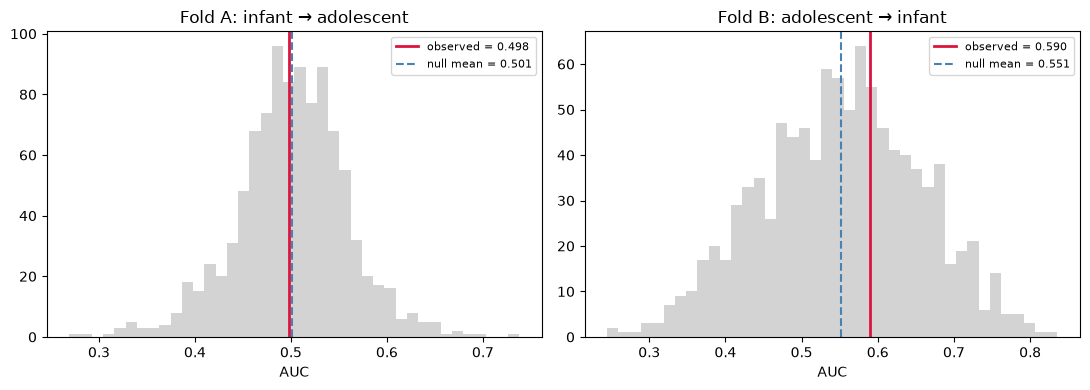

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, null, auc, name in [(axes[0], null_A, auc_A, 'Fold A: infant → adolescent'),
                             (axes[1], null_B, auc_B, 'Fold B: adolescent → infant')]:
    ax.hist(null, bins=40, color='lightgray', edgecolor='none')
    ax.axvline(auc, color='crimson', lw=2, label=f'observed = {auc:.3f}')
    ax.axvline(null.mean(), color='steelblue', ls='--', lw=1.5,
               label=f'null mean = {null.mean():.3f}')
    ax.set_xlabel('AUC'); ax.set_title(name); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{data_dir}/permutation_nulls.png', dpi=150)
plt.show()

Just checking timing before running script separately

In [17]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from collections import Counter

def fold_funnel(Xtr_full, ytr, Xte_full, var_q=0.80, top_n=500, C=1.0):
    v = Xtr_full.var(axis=1)
    keep = Xtr_full.index[v > v.quantile(var_q)]
    _, p = f_classif(Xtr_full.loc[keep].T.values, ytr)
    top = pd.Series(p, index=keep).sort_values().index[:top_n]
    scaler = StandardScaler().fit(Xtr_full.loc[top].T.values)
    Xtr = scaler.transform(Xtr_full.loc[top].T.values)
    clf = LogisticRegression(C=C, max_iter=5000).fit(Xtr, ytr)
    selected = np.array(top)[clf.coef_[0] != 0]
    return clf, scaler.transform(Xte_full.loc[top].T.values), selected

t = time.time()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
for tr, te in cv.split(raw_a.T.values, ya):
    fold_funnel(raw_a.iloc[:, tr], ya[tr], raw_a.iloc[:, te])
print(f"{(time.time()-t)/5:.1f} sec/fold")

0.4 sec/fold


Retrying Classification using significant FDRs as features

In [2]:
import pandas as pd
import numpy as np

data_dir = '/home/ethan-xiao/food-allergy-biomarkers/data'

raw_a = pd.read_csv(f'{data_dir}/raw_114134.csv', index_col=0) #infants
raw_b = pd.read_csv(f'{data_dir}/raw_189148.csv', index_col=0) #adolescents
meta  = pd.read_csv(f'{data_dir}/sample_info.csv')

is_114134 = (meta['cohort'] == 'GSE114134').values
is_189148 = (meta['cohort'] == 'GSE189148').values
y = (meta['allergy_status'] == 'allergic').astype(int).values
ya, yb = y[is_114134], y[is_189148]

print(raw_a.shape, raw_b.shape)
print(len(ya), ya.sum(), len(yb), yb.sum())

(751107, 59) (751107, 43)
59 39 43 28


In [3]:
dmps = ['cg09821461','cg15076659','cg11090352','cg07202532','cg01220651',
        'cg02407224','cg08469540','cg11305394','cg13858061','cg25316898']

isg15_shore = ['cg25610492'] #neighbour of cg08469540
features = dmps + isg15_shore

features = [f for f in features if f in raw_a.index and f in raw_b.index]
print(f"{len(features)} features available in both cohorts")

11 features available in both cohorts


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

Xa = StandardScaler().fit_transform(raw_a.loc[features].T.values)
Xb = StandardScaler().fit_transform(raw_b.loc[features].T.values)

clf = LogisticRegression(C=1, max_iter=5000).fit(Xa, ya)
auc_fixed = roc_auc_score(yb, clf.predict_proba(Xb)[:, 1])
print(f"fixed 11 probe set, infant -> adolescent: {auc_fixed:.3f}")

fixed 11-probe set, infant -> adolescent: 0.543


In [5]:
from sklearn.model_selection import RepeatedStratifiedKFold #Demonstrating difference if we were to use those features to compute a within-cohort classification

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)
aucs = []
for tr, te in cv.split(Xa, ya):
    sc = StandardScaler().fit(Xa[tr])
    c = LogisticRegression(C=1, max_iter=5000).fit(sc.transform(Xa[tr]), ya[tr])
    aucs.append(roc_auc_score(ya[te], c.predict_proba(sc.transform(Xa[te]))[:,1]))
print(f"within-infant CV (biased/data leakage): {np.mean(aucs):.3f} (sd {np.std(aucs):.3f})")

within-infant CV (biased): 0.994 (sd 0.013)


In [6]:
import json #Saving results once again
json.dump({
  'features': features,
  'n_features': len(features),
  'rationale': '10 FDR-significant DMPs from GSE114134 + cg25610492 (ISG15 shore neighbour)',
  'auc_crosscohort_honest': float(auc_fixed),
  'auc_withincohort_CIRCULAR': float(np.mean(aucs)),
  'auc_withincohort_sd': float(np.std(aucs)),
  'note': 'The 0.994 is circular by construction: features were selected using '
          'this cohort, then evaluated on held-out folds of the same cohort. '
          'Reported only as a demonstration of the selection-bias failure mode '
          'documented in Alag 2019 and Kilicarslan 2025. The honest estimate is '
          'the cross-cohort 0.543.'
}, open(f'{data_dir}/fixed_feature_test.json','w'), indent=2)